# Malaria Atlas Project (MAP) - Examples

This notebook demonstrates how to use the Malaria Atlas Project accessor to fetch high spatial resolution malaria data.

## Contents

1. [Setup and Configuration](#setup)
2. [Parasite Rate (PR) Data](#pr-data)
3. [Administrative Boundaries](#admin-boundaries)
4. [Vector Data](#vector-data)
5. [Raster Data](#raster-data)
6. [Malaria Analysis in Brazil](#brazil-analysis)
7. [Malaria Prevalence in Africa](#africa-analysis)

## Documentation

- **MAP Website**: https://data.malariaatlas.org/
- **R Package**: https://github.com/malaria-atlas-project/malariaAtlas
- **API**: WFS/WCS (Web Feature Service / Web Coverage Service)
- **License**: Creative Commons Attribution 3.0

<a id='setup'></a>
## 1. Setup and Configuration

In [1]:
import sys
sys.path.insert(0, '../../scripts/accessors')

from malaria_atlas import MalariaAtlasAccessor
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
map_accessor = MalariaAtlasAccessor()

print("MalariaAtlasAccessor initialized!")

INFO:malaria_atlas:MalariaAtlasAccessor initialized. Cache: /home/fccoelho/.cache/epidemiological_datasets/malaria_atlas


MalariaAtlasAccessor initialized!


<a id='pr-data'></a>
## 2. Parasite Rate (PR) Data

PR (Parasite Rate) data are malaria parasite prevalence measurements obtained through surveys.

In [3]:
pr_versions = map_accessor.list_pr_versions()
print(f"Available PR data versions: {len(pr_versions)}")
print(pr_versions.head())

Available PR data versions: 1
               name                                              title
0  Explorer:PR_Data  PR Surveys<p><small>Village level survey clust...


In [4]:
print("Fetching PR data for Brazil (P. falciparum)...")
pr_pf_brazil = map_accessor.get_pr_data(
    iso="BRA",
    species="Pf"
)
print(f"\nFound {len(pr_pf_brazil)} survey points")

if not pr_pf_brazil.empty:
    print("\nAvailable columns:")
    print(pr_pf_brazil.columns.tolist())

    print("\nFirst rows:")
    print(pr_pf_brazil.head())

INFO:malaria_atlas:Fetching PR data for ['BRA']


Fetching PR data for Brazil (P. falciparum)...


INFO:malaria_atlas:Retrieved 305 PR survey points



Found 305 survey points

Available columns:
['id', 'malaria_metrics_available', 'location_available', 'country', 'country_id', 'continent_id', 'site_id', 'site_name', 'latitude', 'longitude', 'rural_urban', 'month_start', 'year_start', 'month_end', 'year_end', 'lower_age', 'upper_age', 'sample_size', 'pf_positive', 'pf_parasite_rate', 'method', 'rdt_type', 'pcr_type', 'dhs_id', 'permissions_info', 'source_id1', 'title1', 'citation1', 'source_id2', 'title2', 'citation2', 'source_id3', 'title3', 'citation3', 'time_start', 'time_end']

First rows:
       id  malaria_metrics_available  location_available country country_id  \
0  803676                       True                True  Brazil        BRA   
1  803952                      False                True  Brazil        BRA   
2  804082                       True                True  Brazil        BRA   
3  804296                       True                True  Brazil        BRA   
4  804573                       True                T

In [5]:
print("Fetching PR data for Amazon countries...")

amazon_countries = ["BRA", "COL", "PER", "BOL", "ECU"]
pr_amazon = map_accessor.get_pr_data(
    iso=amazon_countries,
    species="Pf",
    start_date="2010-01-01",
    end_date="2020-12-31"
)

print(f"\nTotal survey points in the Amazon region: {len(pr_amazon)}")

if not pr_amazon.empty:
    summary = pr_amazon.groupby('country_id').agg({
        'pf_parasite_rate': ['count', 'mean', 'std']
    }).round(3)
    print("\nSummary by country:")
    print(summary)

INFO:malaria_atlas:Fetching PR data for ['BRA', 'COL', 'PER', 'BOL', 'ECU']


Fetching PR data for Amazon countries...


INFO:malaria_atlas:Retrieved 55 PR survey points



Total survey points in the Amazon region: 55

Summary by country:
           pf_parasite_rate              
                      count   mean    std
country_id                               
BRA                      46  0.004  0.020
COL                       8  0.003  0.005
PER                       1  0.000    NaN


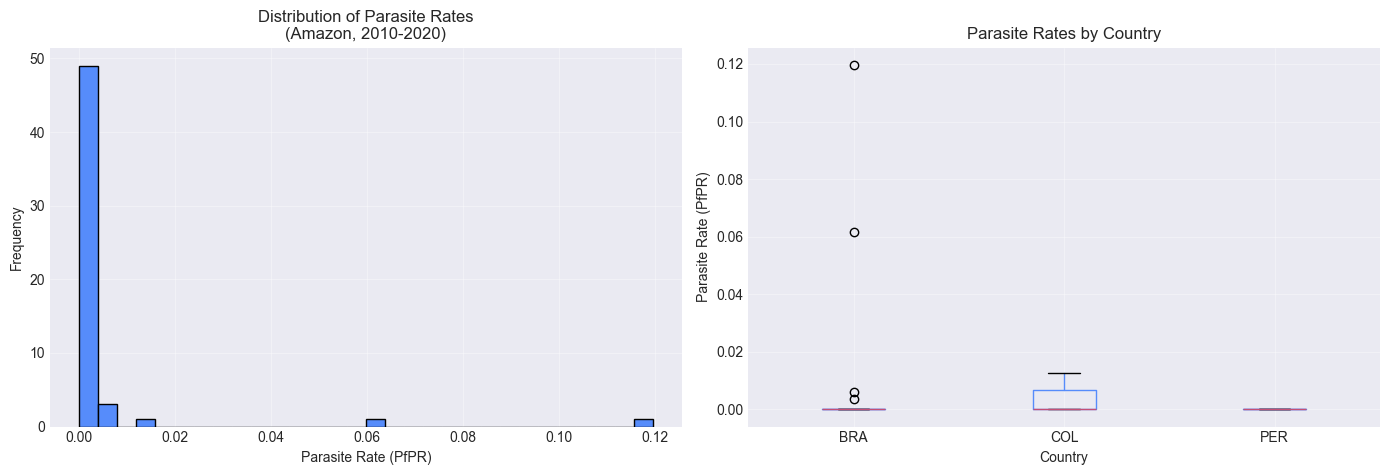

In [6]:
if not pr_amazon.empty and 'pf_parasite_rate' in pr_amazon.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    pr_amazon['pf_parasite_rate'].hist(bins=30, ax=axes[0], edgecolor='black')
    axes[0].set_xlabel('Parasite Rate (PfPR)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Parasite Rates\n(Amazon, 2010-2020)')

    pr_amazon.boxplot(column='pf_parasite_rate', by='country_id', ax=axes[1])
    axes[1].set_xlabel('Country')
    axes[1].set_ylabel('Parasite Rate (PfPR)')
    axes[1].set_title('Parasite Rates by Country')
    plt.suptitle('')

    plt.tight_layout()
    plt.show()

<a id='admin-boundaries'></a>
## 3. Administrative Boundaries

MAP provides administrative boundaries at different levels (admin0-3) for all countries.

In [7]:
countries = map_accessor.list_countries(admin_level="admin0")
print(f"Total countries available: {len(countries)}")
print("\nFirst countries:")
print(countries.head(10))

Total countries available: 249

First countries:
     iso                 name  admin_level
81   AFG          Afghanistan            0
67   ALB              Albania            0
33   DZA              Algeria            0
95   ASM       American Samoa            0
96   AND              Andorra            0
186  AGO               Angola            0
97   AIA             Anguilla            0
98   ATA           Antarctica            0
103  ATG  Antigua and Barbuda            0
94   ARG            Argentina            0


In [8]:
print("Fetching Brazilian state boundaries...")
brazil_states = map_accessor.get_admin_boundaries(
    iso="BRA",
    admin_level="admin1"
)

print(f"\nFound {len(brazil_states)} states")

if not brazil_states.empty:
    print("\nAvailable columns:")
    print(brazil_states.columns.tolist())

    print("\nFirst rows:")
    print(brazil_states[['iso', 'name_0', 'name_1', 'admn_level']].head())

INFO:malaria_atlas:Fetching admin1 boundaries


Fetching Brazilian state boundaries...


INFO:malaria_atlas:Retrieved 27 administrative boundaries



Found 27 states

Available columns:
['gid', 'iso', 'admn_level', 'name_0', 'id_0', 'code_0', 'type_0', 'name_1', 'id_1', 'code_1', 'type_1', 'source', 'iso2', 'geometry']

First rows:
   iso  name_0    name_1  admn_level
0  BRA  Brazil  Rondonia           1
1  BRA  Brazil      Acre           1
2  BRA  Brazil  Amazonas           1
3  BRA  Brazil   Roraima           1
4  BRA  Brazil     Amapa           1


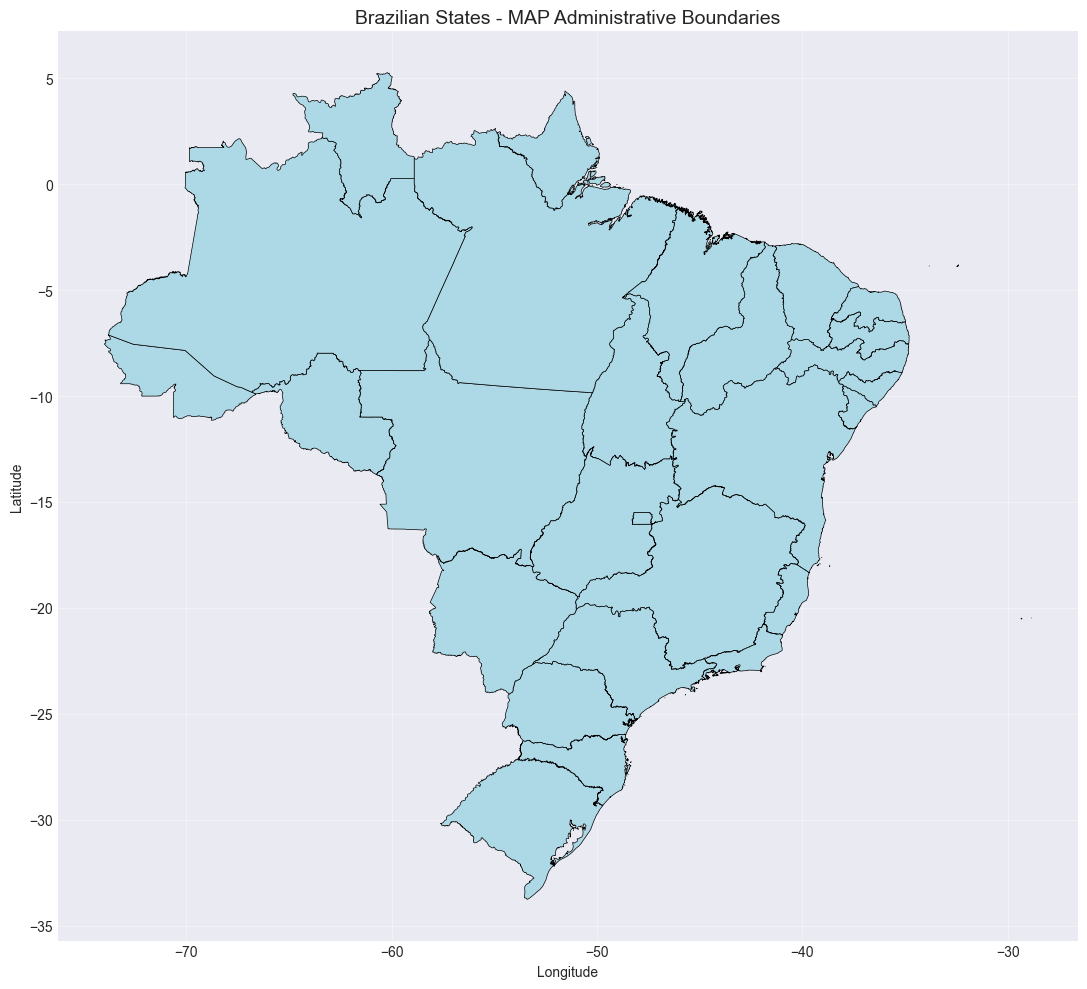

In [9]:
try:
    import geopandas as gpd

    if isinstance(brazil_states, gpd.GeoDataFrame):
        fig, ax = plt.subplots(figsize=(12, 10))
        brazil_states.plot(ax=ax, edgecolor='black', facecolor='lightblue', linewidth=0.5)
        ax.set_title('Brazilian States - MAP Administrative Boundaries', fontsize=14)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        plt.tight_layout()
        plt.show()
    else:
        print("Install geopandas for map visualization")
        print("   pip install geopandas")
except ImportError:
    print("geopandas not installed. Install with: pip install geopandas")
except Exception as e:
    print(f"Error: {e}")

<a id='vector-data'></a>
## 4. Vector Data

Mosquito vector (Anopheles) occurrence data for spatial distribution analysis.

In [10]:
vector_species = map_accessor.list_vector_species()
print(f"Total vector species: {len(vector_species)}")
print("\nMain species:")
print(vector_species.head(15))

Total vector species: 42

Main species:
                   species
0       Anopheles aconitus
1      Anopheles albimanus
2     Anopheles albitarsis
3      Anopheles annularis
4      Anopheles aquasalis
5     Anopheles arabiensis
6     Anopheles atroparvus
7   Anopheles balabacensis
8   Anopheles barbirostris
9       Anopheles coluzzii
10  Anopheles culicifacies
11      Anopheles darlingi
12         Anopheles dirus
13       Anopheles farauti
14  Anopheles flavirostris


In [11]:
print("Fetching Anopheles occurrences in Brazil...")

vector_occurrences = map_accessor.get_vector_occurrence(
    species=["Anopheles darlingi", "Anopheles aquasalis"],
    iso="BRA"
)

print(f"\nFound {len(vector_occurrences)} occurrences")

if not vector_occurrences.empty:
    print("\nAvailable columns:")
    print(vector_occurrences.columns.tolist())

    print("\nSummary by species:")
    print(vector_occurrences['species_plain'].value_counts())

INFO:malaria_atlas:Fetching vector occurrence data


Fetching Anopheles occurrences in Brazil...


INFO:malaria_atlas:Retrieved 395 vector occurrence records



Found 395 occurrences

Available columns:
['id', 'site_id', 'latitude', 'longitude', 'country', 'country_id', 'continent_id', 'month_start', 'year_start', 'month_end', 'year_end', 'anopheline_id', 'species', 'species_plain', 'id_method1', 'id_method2', 'sample_method1', 'sample_method2', 'sample_method3', 'sample_method4', 'assi', 'citation', 'time_start', 'time_end']

Summary by species:
species_plain
Anopheles darlingi     359
Anopheles aquasalis     36
Name: count, dtype: int64


<a id='raster-data'></a>
## 5. Raster Data

High-resolution modeled raster surfaces for malaria burden.

In [12]:
print("Listing available rasters...")
rasters = map_accessor.list_rasters(workspace="Malaria")

print(f"\nFound {len(rasters)} rasters in the Malaria workspace")

print("\nMain rasters:")
for idx, row in rasters.head(10).iterrows():
    print(f"   - {row['title']}")

Listing available rasters...

Found 25 rasters in the Malaria workspace

Main rasters:
   - Reproductive Number under Control within the Limits of stable Plasmodium falciparum Transmission
   - Number of newly diagnosed Plasmodium falciparum cases, on a given year 2000-2020
   - Number of newly diagnosed Plasmodium falciparum cases per 1,000 population, on a given year 2000-2020
   - Number of deaths from Plasmodium falciparum during a defined year 2000-2020
   - Number of deaths from Plasmodium falciparum per 100,000 population during a defined year 2000-2020
   - Proportion of Children 2 to 10 years of age showing, on a given year, detectable Plasmodium falciparum parasite 2000-2020
   - Number of newly diagnosed Plasmodium vivax cases, on a given year 2000-2020
   - Number of newly diagnosed Plasmodium vivax cases per 1,000 population, on a given year 2000-2020
   - Proportion of all population showing, on a given year, detectable Plasmodium vivax parasite 2000-2020
   - Number of n

In [13]:
if not rasters.empty:
    dataset_id = rasters.iloc[0]['dataset_id']

    print(f"Getting info for raster: {dataset_id}")

    raster_info = map_accessor.get_raster_info(dataset_id)

    print("\nRaster information:")
    for key, value in raster_info.items():
        print(f"   {key}: {value}")

Getting info for raster: Malaria__202202_Global_Pf_Reproductive_Number

Raster information:
   dataset_id: Malaria__202202_Global_Pf_Reproductive_Number
   grid_limits: {'low': '0 0', 'high': '6926 2606'}


In [14]:
pfpr_rasters = map_accessor.search_data("PfPR")

if not pfpr_rasters.empty:
    print(f"\nPfPR rasters found: {len(pfpr_rasters)}")
    print(pfpr_rasters[['dataset_id', 'title']].head())

    # Download the first raster (optional - can be large)
    # dataset_id = pfpr_rasters.iloc[0]['dataset_id']
    # raster = map_accessor.download_raster(
    #     dataset_id=dataset_id,
    #     extent=[-74, -34, -34, 5],  # Brazil bounding box
    #     output_path="pfpr_brazil.tif"
    # )
else:
    print("No PfPR rasters found")


PfPR rasters found: 5
                                  dataset_id  \
59                Explorer__2019_Global_PfPR   
58                Explorer__2020_Global_PfPR   
123  Malaria__202206_Global_Pf_Parasite_Rate   
124  Malaria__202406_Global_Pf_Parasite_Rate   
125  Malaria__202508_Global_Pf_Parasite_Rate   

                                                 title  
59   <i>Plasmodium falciparum</i> PR<sub>2 - 10</su...  
58   <i>Plasmodium falciparum</i> PR<sub>2 - 10</su...  
123  Proportion of Children 2 to 10 years of age sh...  
124  Proportion of Children 2 to 10 years of age sh...  
125  Proportion of Children 2 to 10 years of age sh...  


<a id='brazil-analysis'></a>
## 6. Malaria Analysis in Brazil

Integrated analysis example using MAP data.

INFO:malaria_atlas:Fetching PR data for ['BRA']


Analyzing temporal trends of malaria in Brazil...


INFO:malaria_atlas:Retrieved 305 PR survey points



Annual summary:
      year  n_surveys   mean_pr    std_pr
15  2002.0         35  0.014778  0.046885
16  2003.0         24  0.007186  0.018941
17  2004.0         19  0.016883  0.024338
18  2005.0          2  0.013932  0.019703
19  2006.0         19  0.127008  0.214052
20  2008.0          4  0.005589  0.005104
21  2010.0          4  0.032336  0.058268
22  2011.0          3  0.020576  0.035639
23  2012.0          2  0.000000  0.000000
24  2013.0         37  0.000000  0.000000


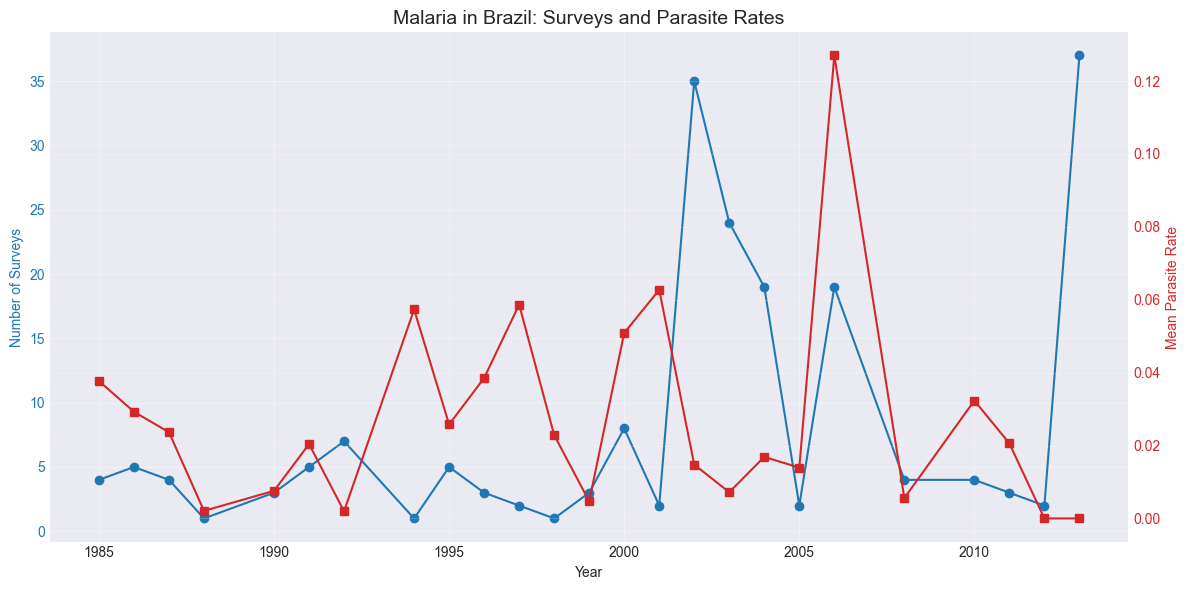

In [15]:
print("Analyzing temporal trends of malaria in Brazil...")

pr_brazil_all = map_accessor.get_pr_data(
    iso="BRA",
    species="Pf"
)

if not pr_brazil_all.empty and 'year_start' in pr_brazil_all.columns:
    pr_brazil_all['year'] = pd.to_numeric(pr_brazil_all['year_start'], errors='coerce')

    yearly_data = pr_brazil_all.groupby('year').agg({
        'pf_parasite_rate': ['count', 'mean', 'std']
    }).reset_index()

    yearly_data.columns = ['year', 'n_surveys', 'mean_pr', 'std_pr']

    print("\nAnnual summary:")
    print(yearly_data.dropna().tail(10))

    fig, ax1 = plt.subplots(figsize=(12, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Number of Surveys', color=color)
    ax1.plot(yearly_data['year'], yearly_data['n_surveys'], color=color, marker='o')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Mean Parasite Rate', color=color)
    ax2.plot(yearly_data['year'], yearly_data['mean_pr'], color=color, marker='s')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Malaria in Brazil: Surveys and Parasite Rates', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

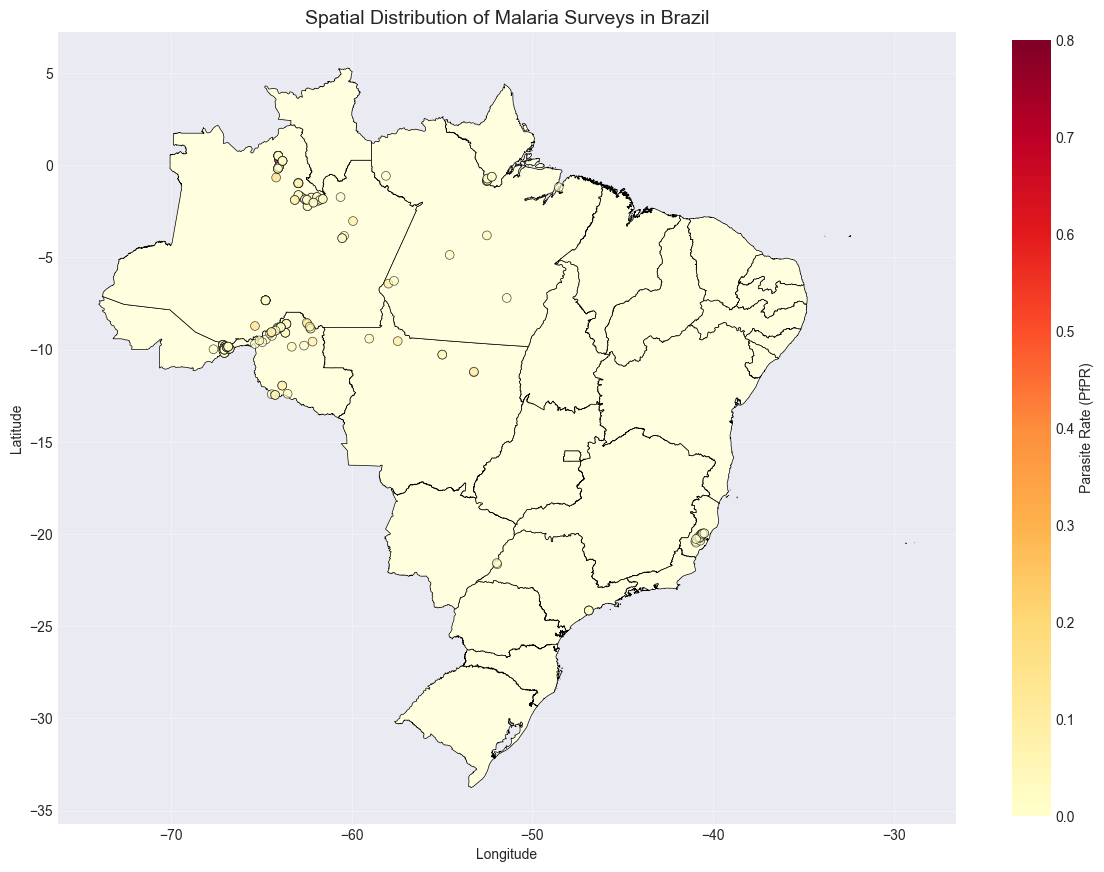

In [16]:
if not pr_brazil_all.empty and 'latitude' in pr_brazil_all.columns:
    import geopandas as gpd
    from shapely.geometry import Point

    survey_gdf = gpd.GeoDataFrame(
        pr_brazil_all,
        geometry=gpd.points_from_xy(pr_brazil_all['longitude'], pr_brazil_all['latitude']),
        crs='EPSG:4326'
    )

    fig, ax = plt.subplots(figsize=(12, 10))
    brazil_states.plot(ax=ax, edgecolor='black', facecolor='lightyellow', linewidth=0.5)

    survey_gdf.plot(
        ax=ax,
        column='pf_parasite_rate',
        cmap='YlOrRd',
        markersize=40,
        alpha=0.7,
        edgecolors='black',
        linewidth=0.5,
        legend=True,
        legend_kwds={'label': 'Parasite Rate (PfPR)', 'shrink': 0.8}
    )

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Spatial Distribution of Malaria Surveys in Brazil', fontsize=14)

    plt.tight_layout()
    plt.show()

<a id='africa-analysis'></a>
## 7. Malaria Prevalence in Africa

Using MAP's WHO AFRO administrative-level data (Annual Parasite Incidence) to assess malaria burden across African countries over the most recent 5 years of available data (2013–2017).

## WHO AFRO Countries

In [17]:
import geopandas as gpd
import shapely.geometry

print("Fetching WHO AFRO admin-level API data...")
resp = map_accessor._wfs_request({
    'typeName': 'MAP_READER:map_data_estate_detail_admin1_api_mean_pf',
    'outputFormat': 'application/json',
    'count': 50000,
    'CQL_FILTER': "who_region = 'AFRO' AND year >= 2013"
})
data = resp.json()

rows, geoms = [], []
for f in data.get('features', []):
    rows.append(f['properties'])
    g = f.get('geometry')
    geoms.append(shapely.geometry.shape(g) if g else None)

afro_df = pd.DataFrame(rows)
print(f"Loaded {len(afro_df)} admin1 records across {afro_df['iso_3_code'].nunique()} countries")
print(f"Years: {sorted(afro_df['year'].unique())}")

Fetching WHO AFRO admin-level API data...
Loaded 325 admin1 records across 16 countries
Years: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]


In [18]:
country_api = afro_df.groupby(['iso_3_code', 'country_name']).agg(
    mean_api=('api_mean_pf', 'mean'),
    total_conf_cases=('conf_c_pf', 'sum'),
    n_records=('id', 'count')
).reset_index().sort_values('mean_api', ascending=False)

print("Mean Annual Parasite Incidence (Pf) by country (2013-2017):")
print(country_api[['country_name', 'mean_api', 'n_records']].to_string(index=False))

Mean Annual Parasite Incidence (Pf) by country (2013-2017):
     country_name    mean_api  n_records
             Chad 1334.239941         21
    Côte d'Ivoire  709.265065          2
     Burkina Faso  536.089649         48
           Zambia  375.967820         10
           Guinea  292.192581         14
Republic Of Congo  291.451750         20
          Senegal  236.879422         28
          Nigeria  121.617121          2
          Namibia   91.541417          1
             Togo   89.930154         10
         Ethiopia   81.688999         55
         Zimbabwe   51.714492         18
          Comoros   44.491108          9
        Swaziland    2.391478          3
       Cape Verde    0.109692         66
     South Africa    0.002707         18


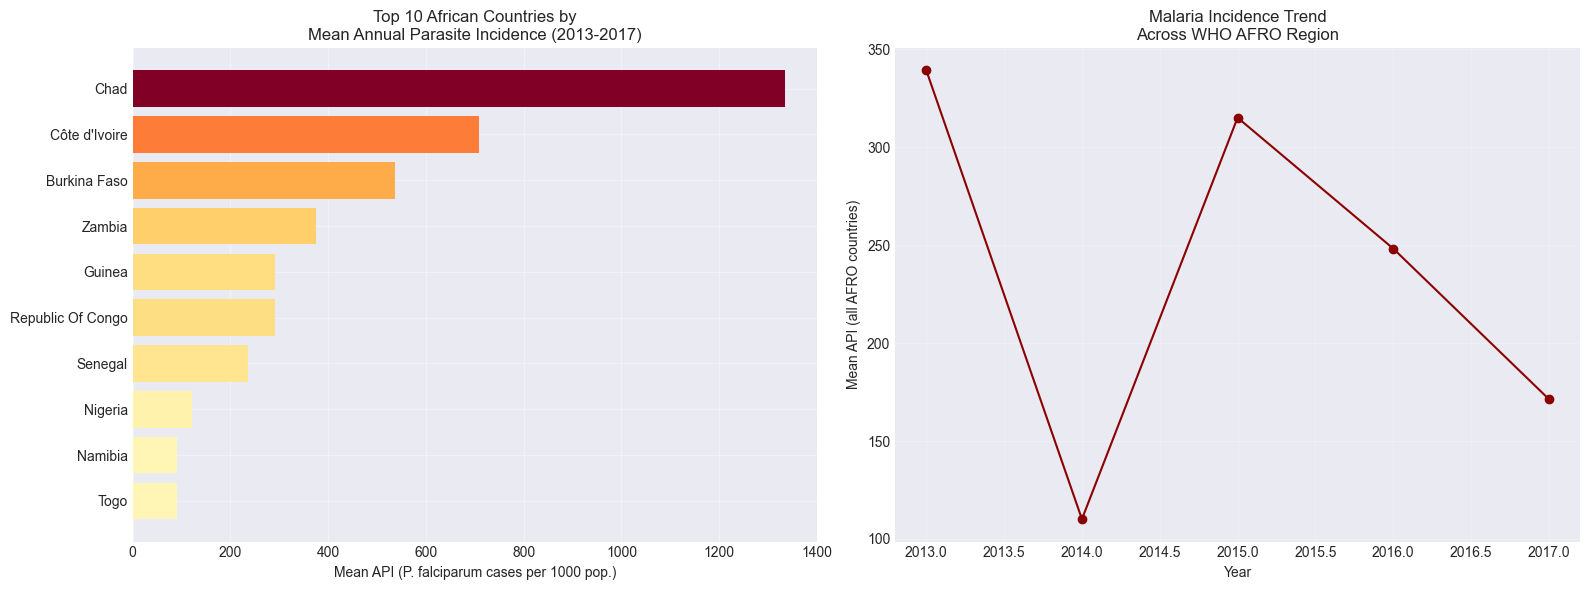

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = country_api.head(10)
colors = plt.cm.YlOrRd(top10['mean_api'] / top10['mean_api'].max())
axes[0].barh(top10['country_name'][::-1], top10['mean_api'][::-1], color=colors[::-1])
axes[0].set_xlabel('Mean API (P. falciparum cases per 1000 pop.)')
axes[0].set_title('Top 10 African Countries by\nMean Annual Parasite Incidence (2013-2017)')

yearly_trend = afro_df.groupby('year').agg(
    mean_api=('api_mean_pf', 'mean'),
    total_cases=('conf_c_pf', 'sum')
).reset_index()
axes[1].plot(yearly_trend['year'], yearly_trend['mean_api'], 'o-', color='darkred')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean API (all AFRO countries)')
axes[1].set_title('Malaria Incidence Trend\nAcross WHO AFRO Region')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Building Africa country-level choropleth...


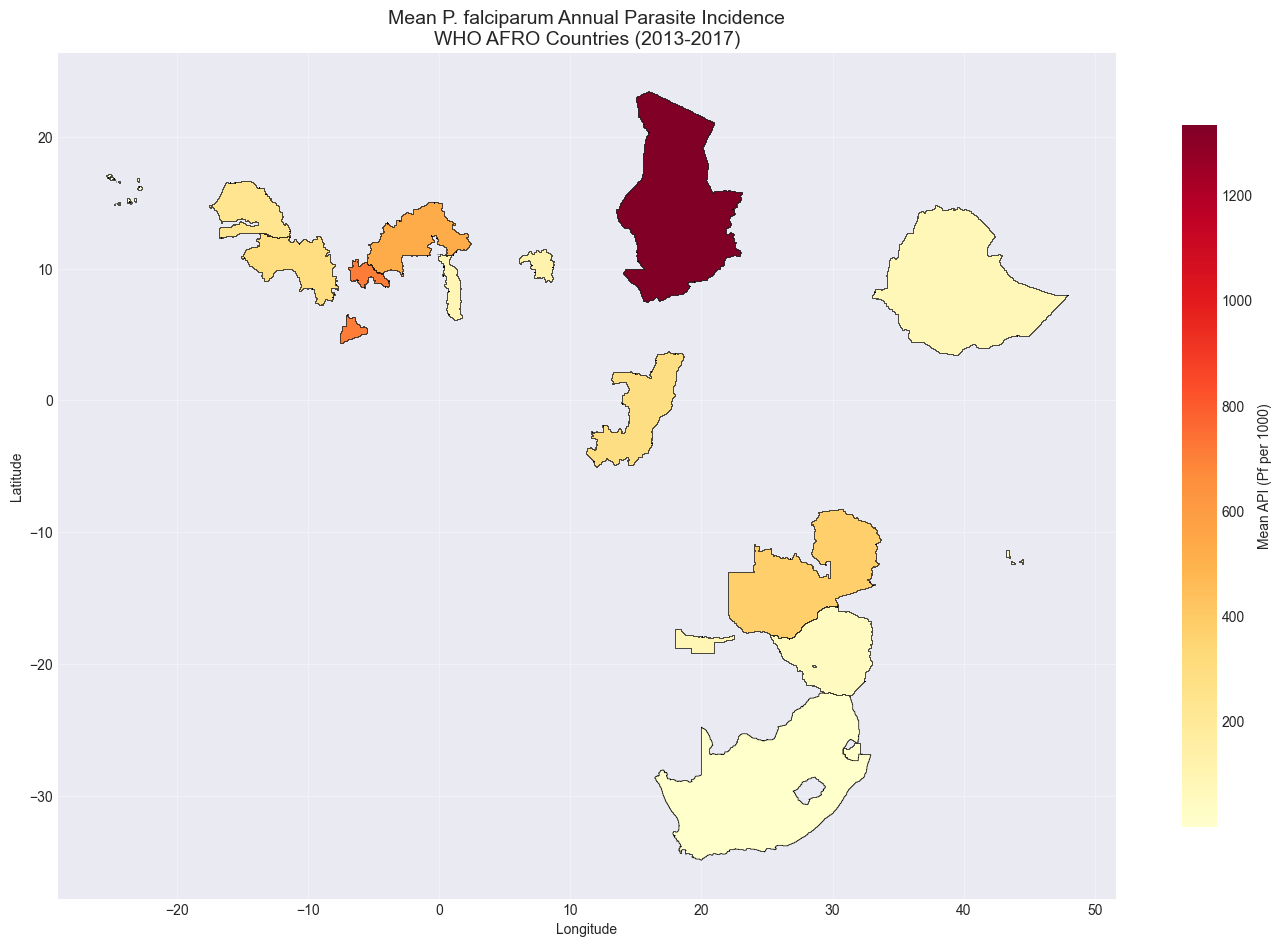

In [20]:
print("Building Africa country-level choropleth...")

afro_gdf = gpd.GeoDataFrame(afro_df, geometry=geoms, crs='EPSG:4326')
country_mean = afro_gdf.dissolve(
    by='iso_3_code',
    aggfunc={'api_mean_pf': 'mean', 'country_name': 'first'}
)

fig, ax = plt.subplots(figsize=(14, 12))
country_mean.plot(
    column='api_mean_pf',
    cmap='YlOrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': 'Mean API (Pf per 1000)', 'shrink': 0.6},
    missing_kwds={'color': 'lightgrey'}
)
ax.set_title('Mean P. falciparum Annual Parasite Incidence\nWHO AFRO Countries (2013-2017)', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

### 7.1 Close-up: Burkina Faso (Admin3 Level)

Burkina Faso has the highest prevalence among countries with admin3-level data. We drill down to district-level API to identify the most affected areas.

In [21]:
top_iso = country_api.iloc[0]['iso_3_code']
top_name = country_api.iloc[0]['country_name']
print(f"Highest-prevalence country: {top_name} ({top_iso})")

print("\nChecking admin3 data availability for top countries...")
for _, row in country_api.head(5).iterrows():
    iso = row['iso_3_code']
    resp3 = map_accessor._wfs_request({
        'typeName': 'MAP_READER:map_data_estate_detail_admin3_api_mean_pf',
        'outputFormat': 'application/json',
        'count': 5,
        'CQL_FILTER': f"iso_3_code = '{iso}'"
    })
    n = resp3.json().get('numberMatched', 0)
    print(f"  {row['country_name']} ({iso}): {n} admin3 records")

closeup_iso = 'BFA'
closeup_name = 'Burkina Faso'
print(f"\nSelected for close-up analysis: {closeup_name} ({closeup_iso})")

Highest-prevalence country: Chad (TCD)

Checking admin3 data availability for top countries...
  Chad (TCD): 0 admin3 records
  Côte d'Ivoire (CIV): 438 admin3 records
  Burkina Faso (BFA): 210 admin3 records
  Zambia (ZMB): 0 admin3 records
  Guinea (GIN): 1 admin3 records

Selected for close-up analysis: Burkina Faso (BFA)


In [22]:
print(f"Fetching admin3 API data for {closeup_name}...")
resp3 = map_accessor._wfs_request({
    'typeName': 'MAP_READER:map_data_estate_detail_admin3_api_mean_pf',
    'outputFormat': 'application/json',
    'count': 5000,
    'CQL_FILTER': f"iso_3_code = '{closeup_iso}'"
})
data3 = resp3.json()

rows3, geoms3 = [], []
for f in data3.get('features', []):
    rows3.append(f['properties'])
    g = f.get('geometry')
    geoms3.append(shapely.geometry.shape(g) if g else None)

bfa3_df = pd.DataFrame(rows3)
print(f"Loaded {len(bfa3_df)} admin3 records")
print(f"Years: {sorted(bfa3_df['year'].unique())}")
print(f"Districts: {bfa3_df['admin_unit'].nunique()}")

Fetching admin3 API data for Burkina Faso...
Loaded 210 admin3 records
Years: [np.int64(2010), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
Districts: 68


In [23]:
district_api = bfa3_df.groupby('admin_unit').agg(
    mean_api=('api_mean_pf', 'mean'),
    max_api=('api_mean_pf', 'max'),
    n_years=('year', 'count')
).reset_index().sort_values('mean_api', ascending=False)

print(f"Top 15 districts in {closeup_name} by mean API:")
print(district_api.head(15).to_string(index=False))

Top 15 districts in Burkina Faso by mean API:
admin_unit     mean_api      max_api  n_years
   Beguedo 40886.309201 68118.247065        3
  Bourasso 13244.469561 13244.469561        1
Bougnounou 10510.842780 17453.855674        3
   Diapaga  7621.133817 10882.862314        4
     Bekuy  5775.128389  8218.861839        3
    Zorgho  5501.694991  8752.763422        3
     Dandé  5389.389033  8639.558146        3
    Sindou  4830.270869  7049.282143        3
     Sebba  4812.458421  7793.999010        4
   Orodara  4656.269601  9653.629173        5
      Dano  4344.052092  7654.868777        3
      Lena  4108.975887  4108.975887        1
    Nanoro  3913.092346  5676.038519        4
 Boussouma  3535.679640  3535.679640        1
     Manga  3447.959769  7057.770285        4


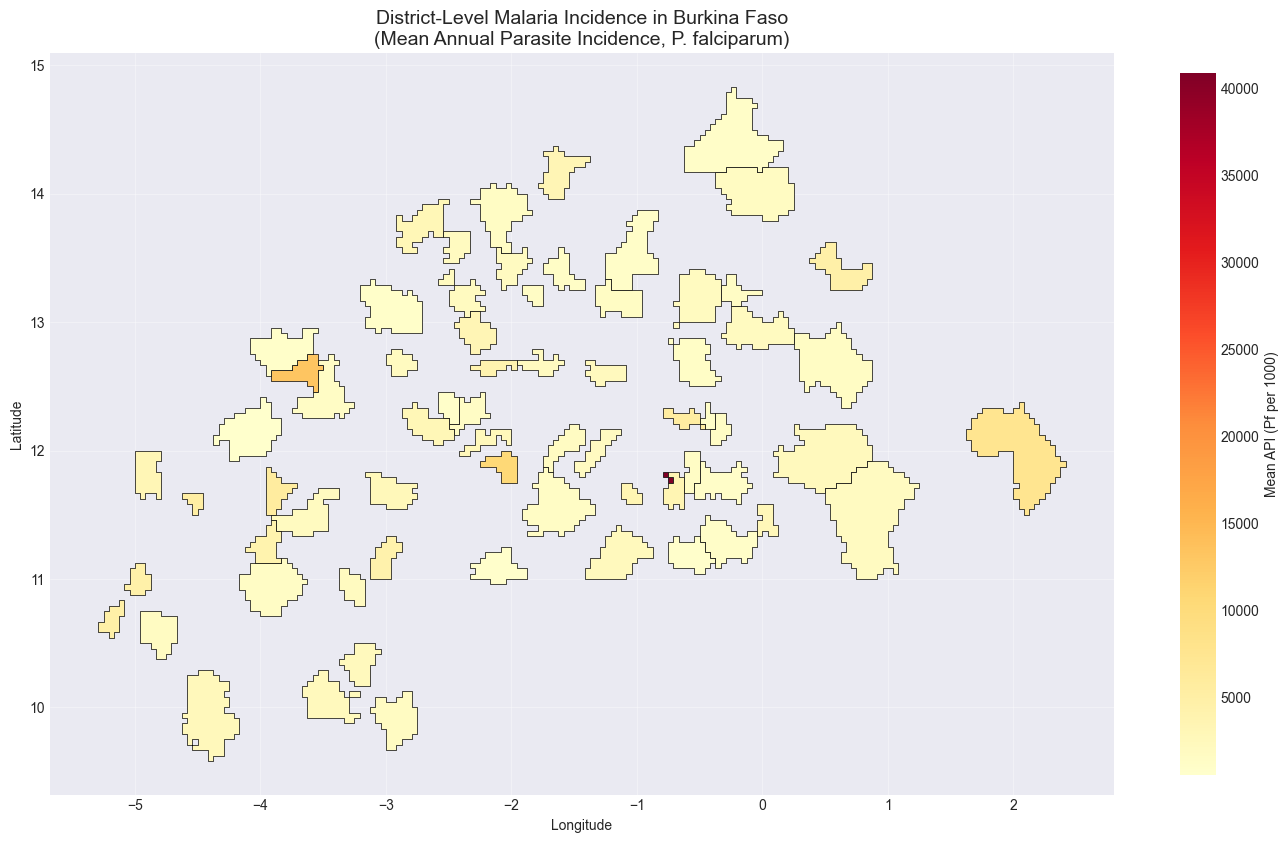

In [24]:
bfa3_gdf = gpd.GeoDataFrame(bfa3_df, geometry=geoms3, crs='EPSG:4326')

district_mean = bfa3_gdf.dissolve(
    by='admin_unit',
    aggfunc={'api_mean_pf': 'mean', 'year': 'count'}
).rename(columns={'api_mean_pf': 'mean_api', 'year': 'n_years'})

fig, ax = plt.subplots(figsize=(14, 12))
district_mean.plot(
    column='mean_api',
    cmap='YlOrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': 'Mean API (Pf per 1000)', 'shrink': 0.6}
)
ax.set_title(f'District-Level Malaria Incidence in {closeup_name}\n(Mean Annual Parasite Incidence, P. falciparum)', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

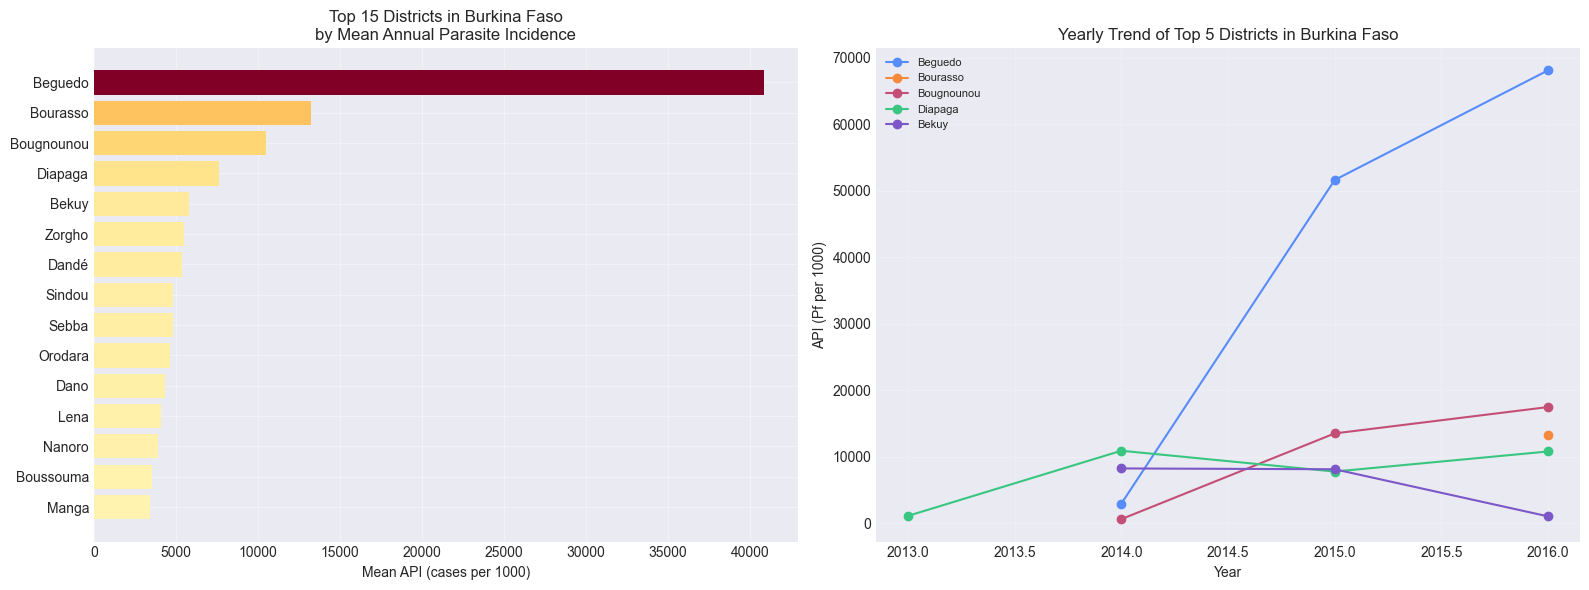

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_districts = district_api.head(15)
colors = plt.cm.YlOrRd(top_districts['mean_api'] / top_districts['mean_api'].max())
axes[0].barh(top_districts['admin_unit'][::-1], top_districts['mean_api'][::-1], color=colors[::-1])
axes[0].set_xlabel('Mean API (cases per 1000)')
axes[0].set_title(f'Top 15 Districts in {closeup_name}\nby Mean Annual Parasite Incidence')

top5_names = district_api.head(5)['admin_unit'].tolist()
for name in top5_names:
    district_year = bfa3_df[bfa3_df['admin_unit'] == name].groupby('year')['api_mean_pf'].mean()
    axes[1].plot(district_year.index, district_year.values, 'o-', label=name)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('API (Pf per 1000)')
axes[1].set_title(f'Yearly Trend of Top 5 Districts in {closeup_name}')
axes[1].legend(fontsize=8, loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:

1. **Setup** of the Malaria Atlas Project accessor
2. **PR Data** - Survey parasite rate measurements
3. **Administrative Boundaries** - Country and state shapefiles
4. **Vector Data** - Anopheles occurrence records
5. **Raster Data** - Modeled malaria surfaces
6. **Integrated Analysis** - Temporal trends in Brazil
7. **Africa Prevalence** - WHO AFRO API choropleth and Burkina Faso admin3 close-up

## Tips for Analysis

- Use **date filters** for specific analysis periods
- Combine **PR + vector** data for risk analysis
- Use **rasters** for high-resolution spatial modeling
- PR data are **point-based** (survey locations), not reported cases

## Additional Resources

- [MAP Documentation](https://malariaatlas.org/)
- [R Package malariaAtlas](https://github.com/malaria-atlas-project/malariaAtlas)
- [MAP Publications](https://malariaatlas.org/publications/)